In [23]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import all 6 classification models 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Load Dataset

In [24]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Dataset Information

In [25]:
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Dataset Info ---")
print(df.info())

--- Dataset Shape ---
(10000, 14)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


# Drop Unnecessary Columns

In [26]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Check Missing Values

In [27]:
print("🔍 Missing Values per Column:")
print(df.isnull().sum())

🔍 Missing Values per Column:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


# Check Duplicates

In [28]:
print(f"👥 Total Duplicate Rows Found: {df.duplicated().sum()}")

👥 Total Duplicate Rows Found: 0


# Encoding

In [29]:
# Convert categorical strings to numerical dummy flags
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


========= VISUALIZATION: OUTLIER DETECTION (BOXPLOTS) =========


C:\Users\Keerthi N Hegde\AppData\Local\Temp\ipykernel_2088\263771434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Exited', y='Age', data=df, palette='Set2')
C:\Users\Keerthi N Hegde\AppData\Local\Temp\ipykernel_2088\263771434.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='Exited', y='CreditScore', data=df, palette='Set2')
C:\Users\Keerthi N Hegde\AppData\Local\Temp\ipykernel_2088\263771434.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], x='Exited', y='Balance', data=df, palette='Set2

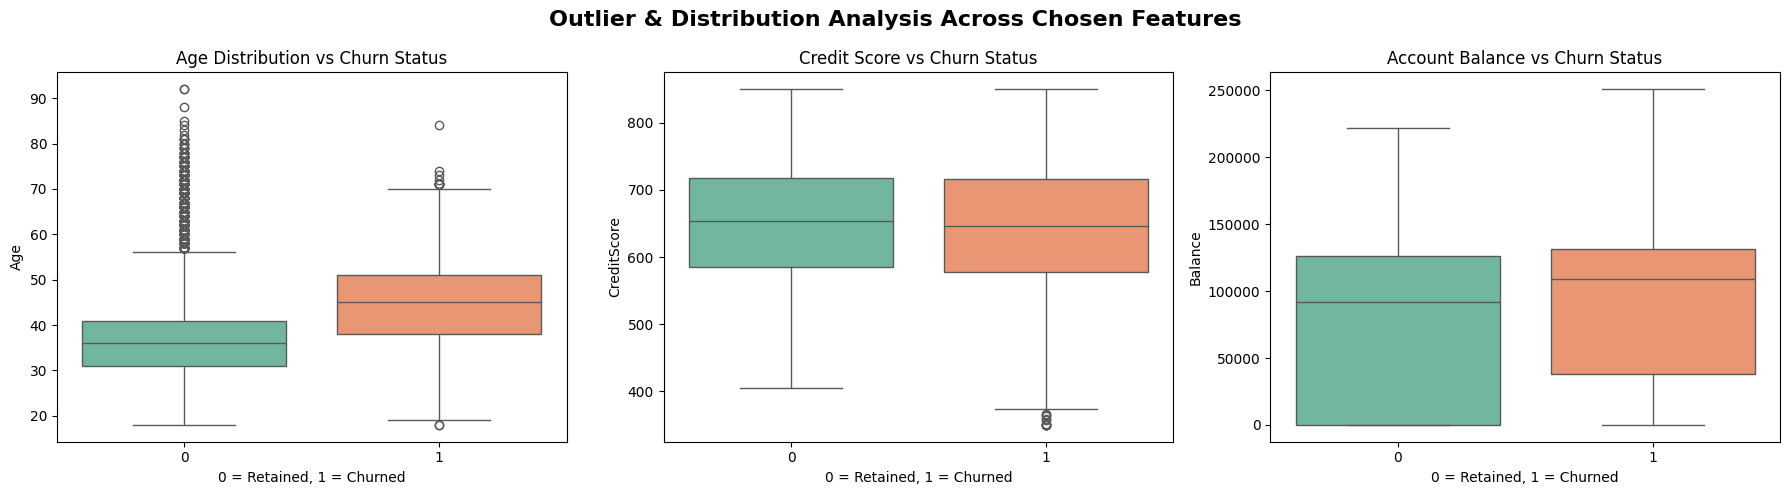

In [41]:
print("========= VISUALIZATION: OUTLIER DETECTION (BOXPLOTS) =========")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], x='Exited', y='Age', data=df, palette='Set2')
axes[0].set_title('Age Distribution vs Churn Status')
axes[0].set_xlabel('0 = Retained, 1 = Churned')

sns.boxplot(ax=axes[1], x='Exited', y='CreditScore', data=df, palette='Set2')
axes[1].set_title('Credit Score vs Churn Status')
axes[1].set_xlabel('0 = Retained, 1 = Churned')

sns.boxplot(ax=axes[2], x='Exited', y='Balance', data=df, palette='Set2')
axes[2].set_title('Account Balance vs Churn Status')
axes[2].set_xlabel('0 = Retained, 1 = Churned')

plt.suptitle("Outlier & Distribution Analysis Across Chosen Features", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#  Define X and y

In [30]:
X = df.drop(columns=['Exited'])
y = df['Exited']

# Train-Test Split & Feature Scaling

In [31]:
# Stratified split to keep imbalanced ratios uniform
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply standard scaling explicitly for distance-based models (KNN, SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Preprocessing and split configurations complete!")

✅ Preprocessing and split configurations complete!


# MULTIPLE MODEL TRAINING & COMPARISON

In [32]:
print("========= PART 2 & 3: MODEL TRAINING & COMPARISON =========")

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled)) * 100

# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test)) * 100

# 3. KNN (Fed with scaled data to ensure accuracy)
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
knn_acc = accuracy_score(y_test, knn.predict(X_test_scaled)) * 100

# 4. Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_acc = accuracy_score(y_test, nb.predict(X_test)) * 100

# 5. SVM (Fed with scaled data to ensure accuracy)
svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test_scaled)) * 100

# 6. Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test)) * 100

# Build final comparison table
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "KNN", "Naive Bayes", "SVM", "Random Forest"],
    "Accuracy (%)": [lr_acc, dt_acc, knn_acc, nb_acc, svm_acc, rf_acc]
})

sorted_results = results_df.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)
print("\n📊 Final Model Performance Ranking:")
print(sorted_results)

========= PART 2 & 3: MODEL TRAINING & COMPARISON =========

📊 Final Model Performance Ranking:
                 Model  Accuracy (%)
0        Random Forest         86.45
1                  SVM         86.10
2                  KNN         82.40
3  Logistic Regression         80.80
4          Naive Bayes         78.65
5        Decision Tree         78.30


# SELECT BEST MODEL & TUNING

In [33]:
print("========= PART 4 & 5: HYPERPARAMETER TUNING =========")

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f"\n🏆 Best Model Selected: Random Forest Classifier")
print(f"Best Parameters Found: {grid_search.best_params_}")

========= PART 4 & 5: HYPERPARAMETER TUNING =========

🏆 Best Model Selected: Random Forest Classifier
Best Parameters Found: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}


#  FINAL MODEL & SAVE MODEL

In [34]:
print("========= PART 6 & 7: FINAL MODEL EVALUATION & EXPORT =========")

final_preds = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_preds) * 100

print(f"🎯 Final Tuned Model Accuracy: {final_accuracy:.2f}%")
print("\n📋 Final Confusion Matrix:")
print(confusion_matrix(y_test, final_preds))
print("\n📋 Final Classification Report:")
print(classification_report(y_test, final_preds))

# Save the trained model file
joblib.dump(best_model, "customer_satisfaction_model.pkl")
print("\n💾 Success: Model saved cleanly as 'customer_satisfaction_model.pkl'!")

========= PART 6 & 7: FINAL MODEL EVALUATION & EXPORT =========
🎯 Final Tuned Model Accuracy: 86.90%

📋 Final Confusion Matrix:
[[1543   50]
 [ 212  195]]

📋 Final Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.84      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000


💾 Success: Model saved cleanly as 'customer_satisfaction_model.pkl'!


========= VISUALIZATION: SELECTED FEATURE IMPORTANCE =========


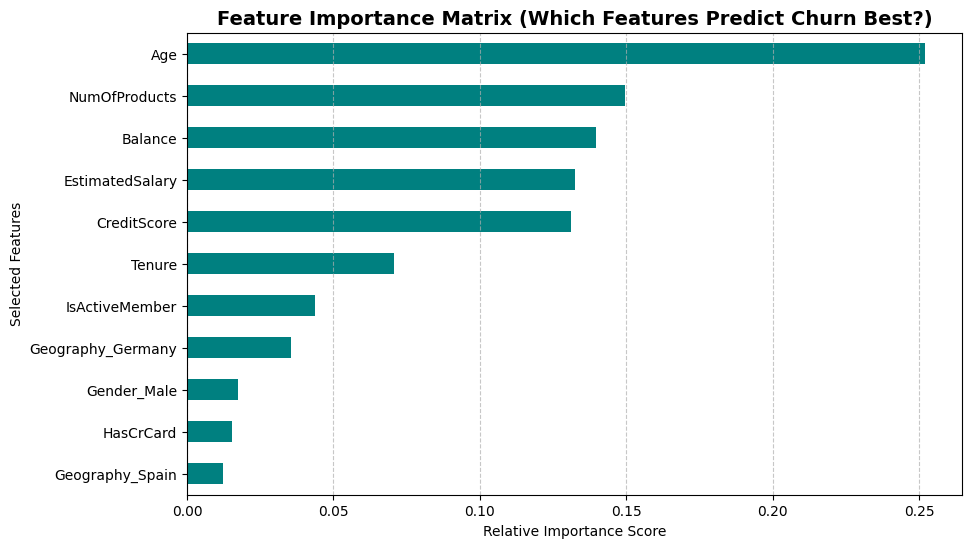

In [40]:
print("========= VISUALIZATION: SELECTED FEATURE IMPORTANCE =========")

# Extract feature importances from your final tuned Random Forest model
importances = best_model.feature_importances_
feature_names = X.columns

# Sort features by importance score
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# Plot the features
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='teal')
plt.title('Feature Importance Matrix (Which Features Predict Churn Best?)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Selected Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()